# Data Exploration
*In this notebook, we explore the IMDB dataset before preprocessing.  
The goal is to understand data structure, class balance, review length, and data quality signals that affect later modeling.*

**1. Imports and data loading:**  
We import the required libraries, load the dataset, and inspect shape, columns, and sample rows.

In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().parent
data_path = project_root / "data" / "IMDB Dataset.csv"
figures_dir = project_root / "results" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: 50,000 rows, 2 columns
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**2. Class distribution:**

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


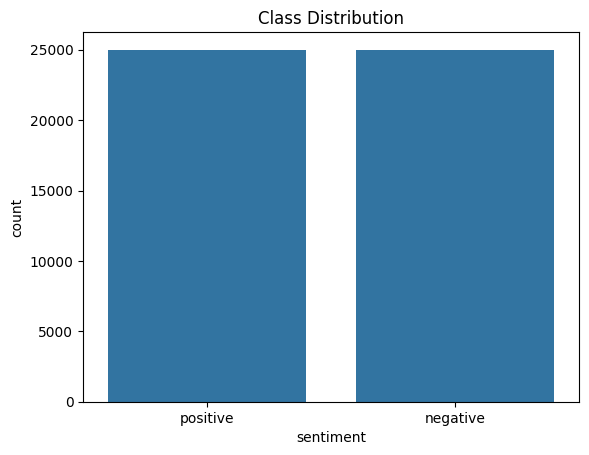

In [2]:
print(df['sentiment'].value_counts())
sns.countplot(x='sentiment', data=df)
plt.title('Class Distribution')
plt.savefig(figures_dir / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**3. Review length analysis:**

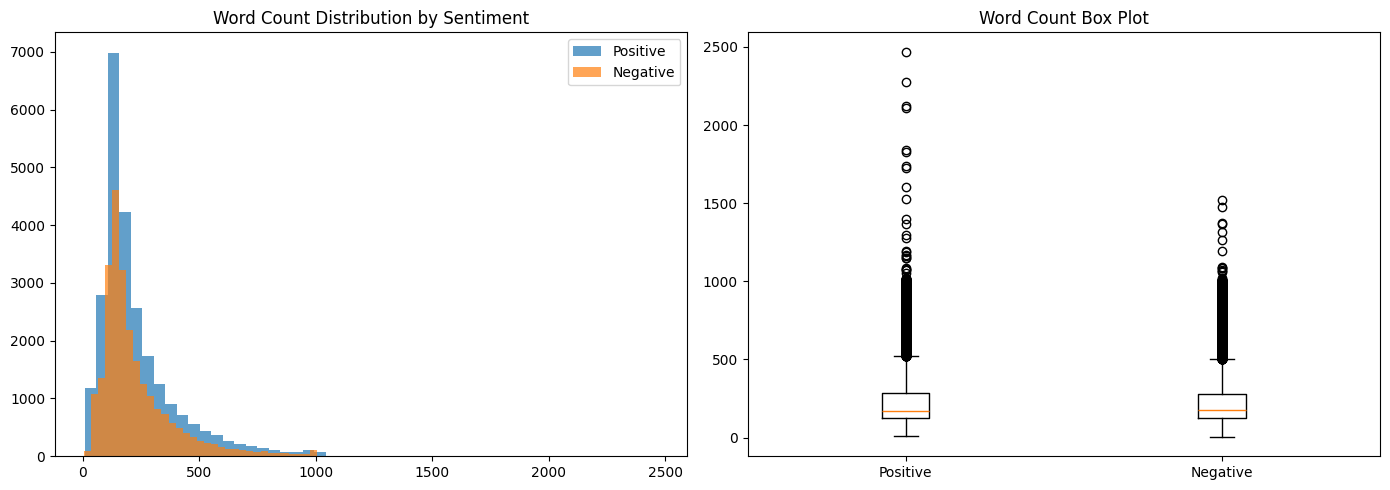

In [3]:
df['review_length'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[df['sentiment'] == 'positive']['word_count'], bins=50, alpha=0.7, label='Positive')
axes[0].hist(df[df['sentiment'] == 'negative']['word_count'], bins=50, alpha=0.7, label='Negative')
axes[0].set_title('Word Count Distribution by Sentiment')
axes[0].legend()

axes[1].boxplot(
    [
        df[df['sentiment'] == 'positive']['word_count'],
        df[df['sentiment'] == 'negative']['word_count'],
    ],
    labels=['Positive', 'Negative'],
)
axes[1].set_title('Word Count Box Plot')
plt.tight_layout()
plt.savefig(figures_dir / 'review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**4. Sample reviews inspection:**

In [4]:
print("=== POSITIVE REVIEW ===")
print(textwrap.fill(df[df['sentiment'] == 'positive']['review'].iloc[0][:500], width=120))
print("\n=== NEGATIVE REVIEW ===")
print(textwrap.fill(df[df['sentiment'] == 'negative']['review'].iloc[0][:500], width=120))

=== POSITIVE REVIEW ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching
scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid.
This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br
/><br />It is called OZ

=== NEGATIVE REVIEW ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting
all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill
the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama!
As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then

**5. Check for HTML tags, duplicates, nulls:**

In [5]:
print(f"Null values:\n{df.isnull().sum()}")
print(f"\nDuplicate reviews: {df.duplicated(subset='review').sum()}")
print(f"\nReviews containing HTML tags: {df['review'].str.contains('<.*?>', regex=True).sum()}")

Null values:
review           0
sentiment        0
review_length    0
word_count       0
dtype: int64

Duplicate reviews: 418

Reviews containing HTML tags: 29202
